<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #4f46e5; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Fundamentos del Aprendizaje Supervisado y Validación Cruzada 🎯🛡️
      </h1>
      <p style="margin: 6px 0 0 0; color: #4f46e5; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Supervised Learning Foundations
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #4338ca; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 02 • Data Mining
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #4f46e5; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Mining/02%20-%20Clasificacion%20y%20Regresion/00_Fundamentos_del_Aprendizaje_Supervisado.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. El Paradigma Supervisado: Aprender de Ejemplos Etiquetados 📚

El **aprendizaje supervisado** parte de un conjunto de entrenamiento $\mathcal{D} = \{(x_1, y_1), \dots, (x_N, y_N)\}$ donde cada observación $x_i \in \mathcal{X}$ (las **variables predictoras** o *features*) viene acompañada de una etiqueta conocida $y_i \in \mathcal{Y}$ (la **variable objetivo**). El objetivo es aprender una función hipótesis $f: \mathcal{X} \to \mathcal{Y}$ que generalice correctamente a observaciones nuevas, no vistas durante el entrenamiento — no basta con memorizar $\mathcal{D}$.

Según la naturaleza de $\mathcal{Y}$, el problema se divide en dos grandes familias:

| Tarea | Naturaleza de $y$ | Pregunta típica | Ejemplo en este módulo |
|---|---|---|---|
| **Clasificación** | Categórica / discreta (a menudo binaria: $y \in \{0, 1\}$) | ¿A qué clase pertenece esta observación? | `clientes_credito.csv`: ¿el cliente incurrirá en `riesgo_default` (0/1)? |
| **Regresión** | Continua ($y \in \mathbb{R}$) | ¿Qué valor numérico se espera? | `inmuebles_precios.csv`: ¿cuál es el `precio_millones` esperado de un inmueble? |

Un caso particular pero extremadamente común en la práctica es la **clasificación desbalanceada**: cuando una de las clases es mucho más rara que la otra (fraude, enfermedades raras, fallas de maquinaria). `transacciones_fraude.csv` (`es_fraude`) es el ejemplo de este cuaderno, y exige tratamiento especial tanto al particionar los datos (Sección 4) como al evaluar el modelo (se retoma en el Cuaderno 04).

A lo largo de este cuaderno se usan estos tres conjuntos de datos reales — nunca datos inventados — para ilustrar cada concepto con cifras verificables.

In [1]:
import os, sys, urllib.request, urllib.parse, gzip, base64

_DATA_EMBEDDED = {
    "clientes_credito.csv": "...",
    "inmuebles_precios.csv": "...",
    "transacciones_fraude.csv": "...",
}

def load_dataset(filename: str) -> str:
    candidates = [
        os.path.join("data", filename),
        os.path.join("..", "data", filename),
        os.path.join("02 - Clasificacion y Regresion", "data", filename),
        os.path.join("Data Mining", "02 - Clasificacion y Regresion", "data", filename),
        os.path.join("..", "02 - Clasificacion y Regresion", "data", filename),
        filename,
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    os.makedirs("data", exist_ok=True)
    target = os.path.join("data", filename)
    base_url = "https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Mining/02%20-%20Clasificacion%20y%20Regresion/data/"
    url = base_url + urllib.parse.quote(filename)
    try:
        urllib.request.urlretrieve(url, target, timeout=3)
        return target
    except Exception:
        pass
    if filename in _DATA_EMBEDDED:
        raw = gzip.decompress(base64.b64decode(_DATA_EMBEDDED[filename]))
        with open(target, "wb") as f:
            f.write(raw)
        return target
    raise FileNotFoundError(f"No se pudo obtener el dataset: {filename}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import os

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

credito = pd.read_csv(load_dataset("clientes_credito.csv"))
inmuebles = pd.read_csv(load_dataset("inmuebles_precios.csv"))
fraude = pd.read_csv(load_dataset("transacciones_fraude.csv"))

print(f"clientes_credito.csv      -> {credito.shape[0]} filas x {credito.shape[1]} columnas")
print(f"inmuebles_precios.csv     -> {inmuebles.shape[0]} filas x {inmuebles.shape[1]} columnas")
print(f"transacciones_fraude.csv  -> {fraude.shape[0]} filas x {fraude.shape[1]} columnas")
display(credito.head(3))
display(inmuebles.head(3))
display(fraude.head(3))

clientes_credito.csv      -> 1200 filas x 7 columnas
inmuebles_precios.csv     -> 1500 filas x 7 columnas
transacciones_fraude.csv  -> 4060 filas x 4 columnas


,id_cliente,edad,ingreso_mensual,antiguedad_laboral_meses,score_credito,ratio_deuda_ingreso,riesgo_default
0,CLI-00001,59,"2,369,054.090",151,596,0.641,1
1,CLI-00002,49,"5,130,004.760",169,396,0.207,0
2,CLI-00003,35,"2,761,600.970",104,595,0.217,0


,id_inmueble,area_m2,habitaciones,estrato,antiguedad_anios,distancia_centro_km,precio_millones
0,INM-00001,88.600,4,4,14,1.870,435.530
1,INM-00002,58.900,2,2,21,0.890,124.100
2,INM-00003,75.300,2,5,31,3.960,446.680


,monto_transaccion,tiempo_respuesta_ms,intentos_previos,es_fraude
0,"150,872.018",131.512,0,0
1,"171,758.668",153.485,1,0
2,"14,241,379.538","2,505.848",6,1


### 1.1 Un primer vistazo a los tres conjuntos de datos 🔎

* **`clientes_credito.csv`** (1200 clientes): variables demográficas y financieras (`edad`, `ingreso_mensual`, `antiguedad_laboral_meses`, `score_credito`, `ratio_deuda_ingreso`) para predecir `riesgo_default` — **clasificación binaria razonablemente balanceada**.
* **`inmuebles_precios.csv`** (1500 inmuebles): características físicas y de ubicación (`area_m2`, `habitaciones`, `estrato`, `antiguedad_anios`, `distancia_centro_km`) para predecir `precio_millones` — **regresión sobre una variable continua**.
* **`transacciones_fraude.csv`** (4060 transacciones): `monto_transaccion`, `tiempo_respuesta_ms`, `intentos_previos` para predecir `es_fraude` — **clasificación binaria fuertemente desbalanceada**.

La celda siguiente cuantifica ese desbalance y confirma que `riesgo_default` sí está razonablemente balanceado, en contraste con `es_fraude`.

In [2]:
print("Balance de clases -- riesgo_default (clientes_credito):")
print(credito["riesgo_default"].value_counts(normalize=True).round(4))

print("\nBalance de clases -- es_fraude (transacciones_fraude):")
print(fraude["es_fraude"].value_counts())
print(fraude["es_fraude"].value_counts(normalize=True).round(4))

print("\nDistribucion de la variable objetivo continua -- precio_millones (inmuebles):")
print(inmuebles["precio_millones"].describe().round(2))

Balance de clases -- riesgo_default (clientes_credito):
riesgo_default
0   0.518
1   0.482
Name: proportion, dtype: float64

Balance de clases -- es_fraude (transacciones_fraude):
es_fraude
0    4000
1      60
Name: count, dtype: int64
es_fraude
0   0.985
1   0.015
Name: proportion, dtype: float64

Distribucion de la variable objetivo continua -- precio_millones (inmuebles):
count   1,500.000
mean      336.180
std       208.530
min        58.690
25%       190.990
50%       276.680
75%       424.360
max     1,343.150
Name: precio_millones, dtype: float64


---
## 2. El Dilema Sesgo-Varianza (*Bias-Variance Trade-off*) ⚖️

El error de generalización esperado de un modelo se puede descomponer, para cada punto $x$, como:

$$\mathbb{E}\big[(y - \hat{f}(x))^2\big] = \underbrace{\big(\mathbb{E}[\hat{f}(x)] - f(x)\big)^2}_{\text{Sesgo}^2} + \underbrace{\mathbb{E}\big[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])^2\big]}_{\text{Varianza}} + \sigma^2_{\epsilon}$$

donde $\sigma^2_{\epsilon}$ es el ruido irreducible del proceso generador de datos. Los otros dos términos sí dependen de la elección del modelo y se mueven en direcciones opuestas:

| | **Alto Sesgo** (*Underfitting*) | **Alta Varianza** (*Overfitting*) |
|---|---|---|
| **Causa** | El modelo es demasiado simple/rígido para capturar la relación real entre $X$ y $y$. | El modelo es demasiado flexible y memoriza particularidades (ruido) del conjunto de entrenamiento. |
| **Síntoma** | Error alto tanto en entrenamiento como en prueba. | Error muy bajo en entrenamiento, error alto en prueba. |
| **Ejemplo típico** | Regresión lineal sobre una relación fuertemente no lineal. | k-NN con $k=1$; un árbol de decisión sin límite de profundidad. |
| **Remedio típico** | Modelo más flexible, más variables predictoras. | Regularización, más datos, reducir la flexibilidad (aumentar $k$, podar el árbol). |

El objetivo práctico nunca es eliminar sesgo o varianza por completo (son términos en tensión), sino encontrar el punto donde su suma —el error total esperado sobre datos nuevos— es mínima. La siguiente sección lo demuestra con dos modelos reales sobre `inmuebles_precios.csv`.

In [3]:
# Un solo predictor (area_m2) para exagerar visualmente el efecto sesgo-varianza
X_biasvar = inmuebles[["area_m2"]]
y_biasvar = inmuebles["precio_millones"]
X_tr, X_te, y_tr, y_te = train_test_split(X_biasvar, y_biasvar, test_size=0.25, random_state=42)

# Modelo RIGIDO: regresion lineal simple (alto sesgo potencial)
modelo_rigido = LinearRegression().fit(X_tr, y_tr)
r2_tr_rigido = r2_score(y_tr, modelo_rigido.predict(X_tr))
r2_te_rigido = r2_score(y_te, modelo_rigido.predict(X_te))
rmse_tr_rigido = np.sqrt(mean_squared_error(y_tr, modelo_rigido.predict(X_tr)))
rmse_te_rigido = np.sqrt(mean_squared_error(y_te, modelo_rigido.predict(X_te)))

# Modelo FLEXIBLE: KNN con k=1 (memoriza el vecino mas cercano, alta varianza potencial)
modelo_flexible = KNeighborsRegressor(n_neighbors=1).fit(X_tr, y_tr)
r2_tr_flex = r2_score(y_tr, modelo_flexible.predict(X_tr))
r2_te_flex = r2_score(y_te, modelo_flexible.predict(X_te))
rmse_tr_flex = np.sqrt(mean_squared_error(y_tr, modelo_flexible.predict(X_tr)))
rmse_te_flex = np.sqrt(mean_squared_error(y_te, modelo_flexible.predict(X_te)))

resultados_bv = pd.DataFrame({
    "modelo": ["LinearRegression (rigido)", "KNN k=1 (flexible)"],
    "R2_train": [r2_tr_rigido, r2_tr_flex],
    "R2_test": [r2_te_rigido, r2_te_flex],
    "RMSE_train": [rmse_tr_rigido, rmse_tr_flex],
    "RMSE_test": [rmse_te_rigido, rmse_te_flex],
})
display(resultados_bv.round(4))

,modelo,R2_train,R2_test,RMSE_train,RMSE_test
0,LinearRegression (rigido),0.281,0.274,181.713,161.272
1,KNN k=1 (flexible),0.471,-0.700,155.858,246.814


**Lectura de los resultados:**

* **`LinearRegression` (rígido):** el $R^2$ de entrenamiento (0.2809) y el de prueba (0.2743) son **similares entre sí — y ambos bajos**. Ese es el patrón de **alto sesgo**: el modelo no está memorizando ruido (no hay gran diferencia train/test), simplemente es demasiado simple (una sola variable, relación lineal) para capturar toda la señal detrás del precio de un inmueble.
* **`KNeighborsRegressor(k=1)` (flexible):** el $R^2$ de entrenamiento es más alto (0.4736, porque con $k=1$ cada punto de entrenamiento es literalmente su propio vecino más cercano — memoriza), pero el $R^2$ de prueba es **negativo (-0.5786)**: el modelo generaliza peor que si simplemente se predijera el precio promedio para cualquier inmueble nuevo. Esa enorme brecha train-test es la firma inconfundible de **alta varianza / sobreajuste**.

Ningún modelo aquí es "mejor" en abstracto — el punto es que ambos fallan, ahora por razones opuestas. La siguiente celda lo visualiza: la recta de `LinearRegression` es suave pero no sigue las curvas reales de los datos, mientras que la curva de `KNN(k=1)` zigzaguea siguiendo cada punto de entrenamiento individual, incluyendo su ruido.

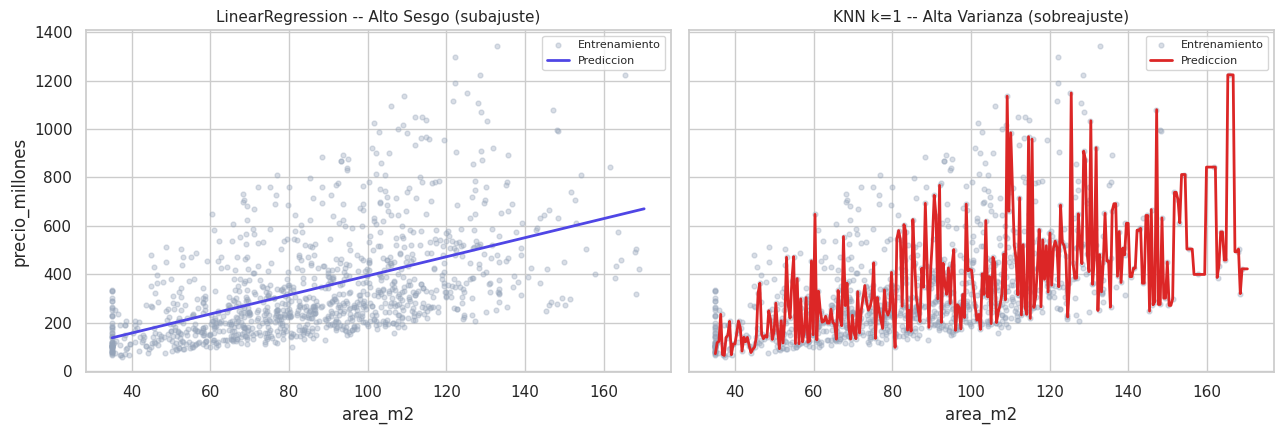

In [4]:
grid_area = np.linspace(X_biasvar["area_m2"].min(), X_biasvar["area_m2"].max(), 300).reshape(-1, 1)
grid_area_df = pd.DataFrame(grid_area, columns=["area_m2"])

pred_rigido_grid = modelo_rigido.predict(grid_area_df)
pred_flex_grid = modelo_flexible.predict(grid_area_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, pred_grid, titulo, color in zip(
    axes, [pred_rigido_grid, pred_flex_grid],
    ["LinearRegression -- Alto Sesgo (subajuste)", "KNN k=1 -- Alta Varianza (sobreajuste)"],
    ["#4f46e5", "#dc2626"],
):
    ax.scatter(X_tr["area_m2"], y_tr, s=12, alpha=0.35, color="#94a3b8", label="Entrenamiento")
    ax.plot(grid_area, pred_grid, color=color, linewidth=2, label="Prediccion")
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("area_m2")
    ax.legend(fontsize=8)
axes[0].set_ylabel("precio_millones")
plt.tight_layout()
plt.show()

---
## 3. Partición Entrenamiento/Prueba: por qué nunca se evalúa sobre los datos de entrenamiento 🚧

La Sección 2 ya mostró el peligro concreto: `KNeighborsRegressor(k=1)` obtuvo un $R^2$ de **entrenamiento** decente (0.4736) que, de haberse reportado como métrica final, habría ocultado por completo que el modelo es prácticamente inútil sobre datos nuevos ($R^2$ de **prueba** = -0.5786). Evaluar sobre el propio conjunto de entrenamiento **siempre** subestima el error real, porque el modelo tuvo la oportunidad de ajustarse (o de memorizar) exactamente esos puntos.

`train_test_split` reserva una fracción de los datos (`test_size`) que el modelo **nunca ve durante `fit`**, y que sirve como una aproximación honesta de "datos nuevos". La siguiente celda repite el experimento con una familia de modelos distinta — árboles de decisión — para confirmar que el patrón no es exclusivo de k-NN.

In [5]:
feat_cols_inm = ["area_m2", "habitaciones", "estrato", "antiguedad_anios", "distancia_centro_km"]
X_tree = inmuebles[feat_cols_inm]
y_tree = inmuebles["precio_millones"]
Xtr_t, Xte_t, ytr_t, yte_t = train_test_split(X_tree, y_tree, test_size=0.25, random_state=42)

arbol_completo = DecisionTreeRegressor(random_state=42).fit(Xtr_t, ytr_t)
arbol_podado = DecisionTreeRegressor(max_depth=3, random_state=42).fit(Xtr_t, ytr_t)

for nombre, modelo in [("Arbol SIN limite de profundidad", arbol_completo), ("Arbol con max_depth=3", arbol_podado)]:
    r2_tr = r2_score(ytr_t, modelo.predict(Xtr_t))
    r2_te = r2_score(yte_t, modelo.predict(Xte_t))
    print(f"{nombre:35s} -> R2 train={r2_tr:.4f}  R2 test={r2_te:.4f}  (brecha={r2_tr - r2_te:.4f})")

Arbol SIN limite de profundidad     -> R2 train=1.0000  R2 test=0.9611  (brecha=0.0389)
Arbol con max_depth=3               -> R2 train=0.8437  R2 test=0.8094  (brecha=0.0343)


**Lectura:** el árbol sin límite de profundidad alcanza un $R^2$ de entrenamiento **perfecto (1.0000)** — memorizó exactamente cada precio de entrenamiento, incluyendo sus particularidades — y aun así generaliza razonablemente bien en este dataset limpio y de solo 5 variables ($R^2$ test = 0.9611): la brecha train-test (≈0.04) existe pero es moderada. El árbol podado a `max_depth=3` sacrifica ajuste en entrenamiento (0.8437) y también reduce algo el desempeño de prueba (0.8094). La lección no es "el árbol completo es malo" — en este caso concreto generaliza bien — sino que **la única forma de saberlo es medir sobre datos que el modelo no vio**; con datos más ruidosos o con más variables irrelevantes, un árbol sin restricciones sí puede sobreajustar dramáticamente, tal como lo hizo k-NN con $k=1$ en la Sección 2.

---
## 4. Particiones Estratificadas: preservando la proporción de clases 🎯

`train_test_split` reparte las filas **al azar** por defecto. Cuando las clases están balanceadas (como `riesgo_default`, ≈52%/48%) esto casi nunca genera problemas. Pero cuando una clase es rara —como `es_fraude`, con apenas 60 casos positivos de 4060 (1.48%)— una partición puramente aleatoria puede, por simple azar, dejar muy pocos (o demasiados) casos positivos en el conjunto de prueba, distorsionando cualquier métrica calculada sobre él.

El parámetro `stratify=y` de `train_test_split` fuerza a que la proporción de cada clase en `y` se preserve, dentro de redondeo, tanto en el conjunto de entrenamiento como en el de prueba. La celda siguiente lo demuestra sobre `es_fraude`.

In [6]:
X_fraude = fraude[["monto_transaccion", "tiempo_respuesta_ms", "intentos_previos"]]
y_fraude = fraude["es_fraude"]

print(f"Proporcion real de fraude en el dataset completo: {y_fraude.mean():.4f} ({y_fraude.sum()} de {len(y_fraude)})")

print("\n--- SIN estratificar (train_test_split normal) ---")
for rs in range(5):
    _, _, _, yte_ns = train_test_split(X_fraude, y_fraude, test_size=0.25, random_state=rs)
    print(f"  random_state={rs}: fraude en test = {yte_ns.sum():3d} casos  (proporcion={yte_ns.mean():.4f})")

print("\n--- CON estratificar (stratify=y_fraude) ---")
for rs in range(5):
    _, _, _, yte_s = train_test_split(X_fraude, y_fraude, test_size=0.25, random_state=rs, stratify=y_fraude)
    print(f"  random_state={rs}: fraude en test = {yte_s.sum():3d} casos  (proporcion={yte_s.mean():.4f})")

Proporcion real de fraude en el dataset completo: 0.0148 (60 de 4060)

--- SIN estratificar (train_test_split normal) ---
  random_state=0: fraude en test =  12 casos  (proporcion=0.0118)
  random_state=1: fraude en test =  16 casos  (proporcion=0.0158)
  random_state=2: fraude en test =  14 casos  (proporcion=0.0138)
  random_state=3: fraude en test =  17 casos  (proporcion=0.0167)
  random_state=4: fraude en test =  17 casos  (proporcion=0.0167)

--- CON estratificar (stratify=y_fraude) ---
  random_state=0: fraude en test =  15 casos  (proporcion=0.0148)
  random_state=1: fraude en test =  15 casos  (proporcion=0.0148)
  random_state=2: fraude en test =  15 casos  (proporcion=0.0148)
  random_state=3: fraude en test =  15 casos  (proporcion=0.0148)
  random_state=4: fraude en test =  15 casos  (proporcion=0.0148)


**Lectura:** sin estratificar, el número de transacciones fraudulentas que caen en el conjunto de prueba varía entre 12 y 17 según la semilla aleatoria (proporción entre 1.18% y 1.67%) — un rango que, sobre apenas ~1015 casos de prueba, puede cambiar sustancialmente el valor de métricas sensibles a la clase minoritaria (recall, por ejemplo). Con `stratify=y_fraude`, el conjunto de prueba contiene **siempre 15 casos de fraude (1.48%)** — exactamente la proporción del dataset completo — sin importar la semilla. La estratificación no reduce el ruido de muestreo a cero, pero elimina una fuente de variabilidad completamente evitable, especialmente crítica en datasets desbalanceados como este.

---
## 5. Validación Cruzada: más allá de una sola partición 🔄

Incluso con estratificación, una **única** partición train/test es solo una muestra del desempeño real del modelo: distintas semillas producen distintas estimaciones de precisión, simplemente porque cada partición deja "casos difíciles" o "casos fáciles" de un lado u otro por azar.

La **validación cruzada k-fold (*k-Fold Cross-Validation*)** aborda esto dividiendo el dataset en $k$ particiones ("folds") de tamaño similar y entrenando/evaluando $k$ veces, usando cada fold como conjunto de prueba exactamente una vez y promediando el resultado:

$$\text{CV}_k = \frac{1}{k}\sum_{i=1}^{k} \text{score}(f_{-i}, \text{fold}_i)$$

donde $f_{-i}$ es el modelo entrenado con todos los folds excepto el $i$-ésimo. El resultado no es solo una media más estable, sino también una **desviación estándar entre folds**, que cuantifica cuánto varía el desempeño según qué datos se usan para evaluar — información que una sola partición jamás puede dar. `StratifiedKFold` aplica el mismo principio de la Sección 4 a cada uno de los $k$ folds.

In [7]:
feat_cols_cred = ["edad", "ingreso_mensual", "antiguedad_laboral_meses", "score_credito", "ratio_deuda_ingreso"]
X_cred = credito[feat_cols_cred]
y_cred = credito["riesgo_default"]

print("--- Una sola particion (holdout), accuracy segun la semilla ---")
for rs in range(5):
    Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(X_cred, y_cred, test_size=0.25, random_state=rs, stratify=y_cred)
    modelo_c = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    modelo_c.fit(Xtr_c, ytr_c)
    print(f"  random_state={rs}: accuracy = {modelo_c.score(Xte_c, yte_c):.4f}")

modelo_cv = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores_kf = cross_val_score(modelo_cv, X_cred, y_cred, cv=kf, scoring="accuracy")
print(f"\nKFold (5 folds)            -> scores={np.round(scores_kf, 4)}")
print(f"                              media={scores_kf.mean():.4f}  std={scores_kf.std():.4f}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_skf = cross_val_score(modelo_cv, X_cred, y_cred, cv=skf, scoring="accuracy")
print(f"StratifiedKFold (5 folds)  -> scores={np.round(scores_skf, 4)}")
print(f"                              media={scores_skf.mean():.4f}  std={scores_skf.std():.4f}")

--- Una sola particion (holdout), accuracy segun la semilla ---
  random_state=0: accuracy = 0.7733
  random_state=1: accuracy = 0.7433
  random_state=2: accuracy = 0.7133
  random_state=3: accuracy = 0.7000
  random_state=4: accuracy = 0.7100

KFold (5 folds)            -> scores=[0.7333 0.7333 0.7625 0.7625 0.7375]
                              media=0.7458  std=0.0137
StratifiedKFold (5 folds)  -> scores=[0.75   0.7333 0.7125 0.7542 0.7542]
                              media=0.7408  std=0.0161


**Lectura:** la precisión de una sola partición varía entre **0.70 y 0.77** según la semilla — un rango de 7 puntos porcentuales que podría hacer parecer un modelo "bueno" o "mediocre" dependiendo únicamente de qué fila terminó en el conjunto de prueba. `cross_val_score` con `KFold` produce 5 estimaciones (0.7333 a 0.7625, media 0.7458, std 0.0137) que **promedian ese ruido** en lugar de depender de una sola muestra; `StratifiedKFold` hace lo mismo preservando además la proporción ≈52%/48% de `riesgo_default` en cada fold (media 0.7408, std 0.0161). En un dataset tan balanceado como este la diferencia entre `KFold` y `StratifiedKFold` es pequeña, pero en un dataset desbalanceado como `transacciones_fraude.csv` (Sección 4) la elección deja de ser opcional: sin estratificar, algún fold podría terminar con muy pocos (o cero) casos de fraude, invalidando cualquier métrica calculada sobre esa iteración.

---
## 6. Tabla Comparativa: Holdout vs. K-Fold vs. Stratified K-Fold 📊

| Estrategia | Cómo funciona | Ventaja principal | Desventaja principal | Cuándo usarla |
|---|---|---|---|---|
| **Holdout simple** (`train_test_split`) | Una única partición train/test. | Rápida, barata computacionalmente (un solo entrenamiento). | Estimación con alta varianza — depende de la semilla aleatoria (Sección 5: rango 0.70-0.77 en este dataset). | Datasets muy grandes donde entrenar $k$ veces es costoso; prototipado rápido. |
| **K-Fold CV** (`KFold` + `cross_val_score`) | $k$ particiones, cada una usada una vez como prueba; se promedia. | Estimación más estable (media + desviación estándar entre folds). | $k$ veces más costoso computacionalmente que un holdout; no preserva proporciones de clase. | Regresión, o clasificación con clases razonablemente balanceadas. |
| **Stratified K-Fold** (`StratifiedKFold`) | Igual que K-Fold, pero preservando la proporción de clases en cada fold. | Evita folds con muy pocos (o ningún) caso de la clase minoritaria. | Mismo costo computacional que K-Fold; solo aplica a clasificación. | **Siempre** que la tarea sea de clasificación, y especialmente con clases desbalanceadas (`es_fraude`). |

**Regla práctica de este curso:** usar `train_test_split(..., stratify=y)` como partición final para reportar el modelo elegido, pero usar `StratifiedKFold` (clasificación) o `KFold` (regresión) durante la fase de selección y comparación de modelos — es la única forma de saber si una diferencia de desempeño entre dos modelos es real o es ruido de partición.

---
## 7. Ejercicio Práctico Guiado: Validación Cruzada Estratificada sobre `transacciones_fraude.csv` 📝

**Contexto:** `es_fraude` es la variable objetivo más desbalanceada de las tres (1.48% de casos positivos). Vas a construir un pipeline de clasificación completo y evaluarlo con validación cruzada estratificada, tal como se recomienda en la Sección 6.

**Tu misión:**
1. Define `X` con las columnas `["monto_transaccion", "tiempo_respuesta_ms", "intentos_previos"]` de `fraude`, y `y` con `fraude["es_fraude"]`.
2. Crea un `StratifiedKFold` con `n_splits=5`, `shuffle=True` y `random_state=42`.
3. Crea un pipeline con `StandardScaler` seguido de `LogisticRegression(max_iter=1000)`.
4. Ejecuta `cross_val_score` con `scoring="accuracy"` usando el `StratifiedKFold` del paso 2.
5. Imprime los scores de cada fold, su media y su desviación estándar.
6. Calcula también la exactitud de un modelo trivial que siempre predice la clase mayoritaria (`(y == 0).mean()`) y compárala con la media obtenida en el paso 5.

In [8]:
### TU CODIGO AQUI ###
# 1. Define X e y
X_ejercicio = None
y_ejercicio = None

# 2. Crea el StratifiedKFold
skf_ejercicio = None

# 3. Crea el pipeline (StandardScaler + LogisticRegression)
pipeline_ejercicio = None

# 4. Ejecuta cross_val_score con scoring="accuracy"
scores_ejercicio = None

# 5. Imprime scores, media y desviacion estandar
print("Scores por fold:", None)
print("Media:", None)
print("Desviacion estandar:", None)

# 6. Compara contra el modelo trivial (siempre predice la clase mayoritaria)
accuracy_trivial = None
print("\nAccuracy del modelo trivial (siempre predice 'no fraude'):", accuracy_trivial)

Scores por fold: None
Media: None
Desviacion estandar: None

Accuracy del modelo trivial (siempre predice 'no fraude'): None


<details>
<summary>💡 Ver solución propuesta</summary>

```python
# 1. Define X e y
X_ejercicio = fraude[["monto_transaccion", "tiempo_respuesta_ms", "intentos_previos"]]
y_ejercicio = fraude["es_fraude"]

# 2. Crea el StratifiedKFold
skf_ejercicio = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Crea el pipeline (StandardScaler + LogisticRegression)
pipeline_ejercicio = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

# 4. Ejecuta cross_val_score con scoring="accuracy"
scores_ejercicio = cross_val_score(pipeline_ejercicio, X_ejercicio, y_ejercicio, cv=skf_ejercicio, scoring="accuracy")

# 5. Imprime scores, media y desviacion estandar
print("Scores por fold:", np.round(scores_ejercicio, 4))
print("Media:", round(scores_ejercicio.mean(), 4))
print("Desviacion estandar:", round(scores_ejercicio.std(), 4))

# 6. Compara contra el modelo trivial (siempre predice la clase mayoritaria)
accuracy_trivial = (y_ejercicio == 0).mean()
print("\nAccuracy del modelo trivial (siempre predice 'no fraude'):", round(accuracy_trivial, 4))
```

Con este pipeline, `cross_val_score` obtiene una media de accuracy perfecta (1.0000 en los 5 folds), muy por encima del 98.52% del modelo trivial que siempre predice "no fraude". En este dataset en particular, `monto_transaccion` es un predictor casi perfecto (los montos fraudulentos son órdenes de magnitud mayores a los normales), así que la separación resulta casi trivial para el modelo. Aun así, la accuracy sigue siendo una métrica que puede ocultar problemas reales: con una clase tan rara, un solo fold desafortunado con pocos positivos, o un dataset menos "limpio" que este, bastaría para que la accuracy global se mantenga alta mientras el modelo falla sistemáticamente en detectar fraude. Precisión, recall y F1 -- introducidas en el Cuaderno 04 -- son las métricas que exponen ese tipo de fallas, que accuracy por sí sola no puede revelar.

</details>

---
## 8. Resumen Ejecutivo del Cuaderno 00 📌

1. **El aprendizaje supervisado se divide en clasificación (`riesgo_default`, `es_fraude`) y regresión (`precio_millones`)** según si la variable objetivo es categórica o continua; el desbalance de clases (`es_fraude`, 1.48% positivos) exige tratamiento especial en cada etapa del flujo de trabajo.
2. **El dilema sesgo-varianza es medible, no solo teórico:** sobre `inmuebles_precios.csv`, `LinearRegression` con una sola variable mostró alto sesgo ($R^2$ train≈test≈0.28), mientras que `KNeighborsRegressor(k=1)` mostró alta varianza ($R^2$ train=0.4736 pero test=-0.5786, peor que predecir la media).
3. **Nunca se evalúa un modelo sobre los datos que vio durante el entrenamiento:** el árbol de decisión sin restricciones alcanzó $R^2$=1.0 en entrenamiento, una cifra sin ningún valor diagnóstico por sí sola.
4. **La estratificación (`stratify=y`) es indispensable en datos desbalanceados:** sin ella, el número de casos de fraude en el conjunto de prueba varió entre 12 y 17 según la semilla; con ella, se mantuvo constante en 15 (1.48%), igual que en el dataset completo.
5. **Una sola partición es una estimación ruidosa del desempeño real:** la accuracy de un holdout sobre `clientes_credito.csv` varió entre 0.70 y 0.77 según la semilla; `StratifiedKFold` (5 folds) la resume en una media (0.7408) y una desviación estándar (0.0161) que cuantifican esa incertidumbre de forma explícita.
6. **Siguiente paso:** el **Cuaderno 01** introduce el primer algoritmo concreto del módulo, **k-Nearest Neighbors**, y retoma directamente el problema de $k=1$ sobreajustando que se demostró en la Sección 2.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Minería de Datos | Clasificación y Regresión</i>
  </p>
</div>